In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [12]:
class QuadState(TypedDict):

    a:int
    b:int
    c:int

    equation:str
    discriminant:str
    result:str

In [13]:
def Show_Equation(state:QuadState):

    equation=f"{state['a']}x2 + {state['b']}x + {state['c']}"
    return {"equation":equation}

def Calculate_Discriminant(state:QuadState):
    
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant' : discriminant}

def Real_Roots(state:QuadState):

    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])

    result = f"The Real Roots are {root1} and {root2}"

    return {"result" : result}

def Repeated_Roots(state:QuadState):

    root = (state['b']) / (2*state['a'])

    result = f"Repeating Root is {root}"

    return {"result" : result}

def No_Real_Roots(state:QuadState):

    result = "No Real Roots for this Quadratic Equation"

    return {"result" : result}

def Check_Condition(state:QuadState) -> Literal["Real_Roots","Repeated_Roots","No_Real_Roots"]:

    if state['discriminant'] > 0:
        return "Real_Roots"
    elif state['discriminant'] == 0:
        return "Repeated_Roots"
    else:
        return "No_Real_Roots"

In [14]:
graph = StateGraph(QuadState)

graph.add_node("Show_Equation",Show_Equation)
graph.add_node("Calculate_Discriminant",Calculate_Discriminant)
graph.add_node("Real_Roots",Real_Roots)
graph.add_node("Repeated_Roots",Repeated_Roots)
graph.add_node("No_Real_Roots",No_Real_Roots)

graph.add_edge(START,"Show_Equation")
graph.add_edge("Show_Equation","Calculate_Discriminant")
graph.add_conditional_edges("Calculate_Discriminant",Check_Condition)
graph.add_edge("Real_Roots",END)
graph.add_edge("Repeated_Roots",END)
graph.add_edge("No_Real_Roots",END)

workflow = graph.compile()

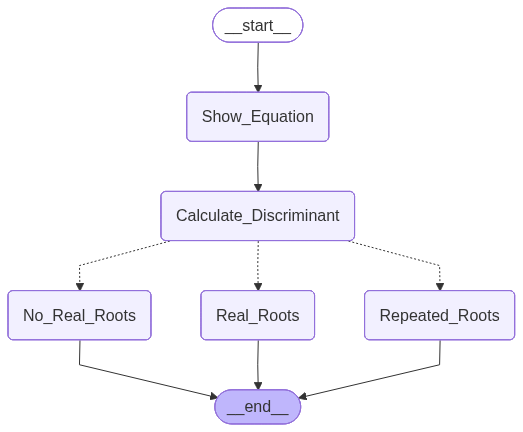

In [15]:
workflow

In [16]:
initial_state={
    'a':4,
    'b':2,
    'c':-5
}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': 2, 'c': -5, 'equation': '4x2 + 2x + -5', 'discriminant': 84, 'result': 'The Real Roots are 0.89564392373896 and -1.39564392373896'}
